# Analyse Elmer/Ice runs against observations

Compares one or more model runs against satellite observations: grounding-line
discharge and mass balance per Mouginot catchment (§1a), 2D velocity / dH/dt maps
vs obs (§1b), and run-vs-run difference maps (§1c).

Declare the runs in `RUNS` in the config cell below — every §1a plot then draws
one line per run. Per-catchment diagnostics are cached, so re-running is instant.

Shared setup — mesh geometry, flux integrators, per-member diagnostics — lives in
`elmer_analysis.py`. **Ensemble analysis is in `AnalyseEnsemble.ipynb`.**

## §0 — Configuration & setup

In [11]:
import numpy as np
import pandas as pd
import xarray as xr
import xugrid as xu
import matplotlib.pyplot as plt
import proplot as pplt              # figure styling used by the line plots
import itertools
from itertools import combinations as iter_combinations
from pathlib import Path
# Requires in the env: xugrid, xarray, proplot, cftime (for 360_day obs calendars).

In [ ]:
import elmer_analysis as ea

# ── EDIT ME: declare the runs you want to compare ───────────────────────────
# label -> (states file, forcing file). The first run defines the mesh.
# Labels show up in legends, figure names and the diagnostics cache, so keep
# them short and stable.
RUNS = {
    "baseline":    ("../DATA/states_ocx.nc",             "../DATA/forcing_ocx.nc"),
    # "fric0_shelf": ("../DATA/states_ocx_fric0_shelf.nc", "../DATA/forcing_ocx_fric0_shelf.nc"),
}

CONFIG = ea.Config(
    # ElmerUgrid checkout (see README) -- registers .ugrid.to_netcdf_forpv
    postpro_dir   = "/home/jagereli/Postdoc/Data/postpro/elmerugrid",

    member_kind   = "ocx",
    runs          = RUNS,

    # Mesh-specific products for THAT mesh, from preprocessing/build_mesh_products.py
    basins_file   = "../DATA/basins_mouginotGrid_ocx.nc",
    obs_mesh_file = "../DATA/obs_on_elmer_mesh_pv_ocx.nc",

    # Raw observations (see DATA/README.md for download links)
    obs_ismip_file     = "../DATA/AntarcticaObsISMIP7-v1.2.nc",
    obs_discharge_file = "../DATA/AIS_discharge_BMHF14.nc",
)

# Loads the mesh, basins and observations, and brings the shared names
# (times, basins, basin_ids, face_areas, node_to_face, savefig, load_runs, ...)
# into scope.
globals().update(ea.init(CONFIG))

## §1 — Single / averaged member vs observations

### 1a — Global: discharge & mass change by catchment

In [ ]:
# Per-catchment mass budget (SMB, BMB, calving, GL discharge) for every run in
# RUNS, as ONE dataset with a `run` dimension:  members["gl_discharge"].sel(run=...)
#
# Computing this reads the whole states+forcing files and integrates every year x
# basin -- minutes -- but the result is only a few hundred kB, so it is CACHED to
# diag_cache/. Re-running this cell is then instant. The cache is invalidated
# automatically if a states/forcing file is newer than it (i.e. you re-ran the
# model), so you cannot silently plot stale numbers. Force a rebuild with
# load_runs(force=True).
members = load_runs()
print("\nRuns loaded:", list(members["run"].values))
members

In [14]:
# Observed grounding-line discharge (BMHF14 / IMBIE), or None if the file is absent.
obs_disch = load_obs_discharge()

In [ ]:
# Colour per run; obs stays red throughout.
RUN_COLORS = ["tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:brown", "tab:cyan"]


def plot_member_by_catchment(members, variable="gl_discharge",
                             obs=obs_disch, overlay_obs=True):
    """3x6 grid, one Mouginot catchment per panel: one line per run (+ obs discharge)."""
    cids = [c for c in members["catchment"].values if 1 <= int(c) <= 18]
    fig, axes = pplt.subplots(nrows=3, ncols=6, figsize=(18, 9),
                              sharey=False, sharex=True, hspace=0.5, wspace=0.4)
    for ax, cid in zip(axes, cids):
        for i, (label, ds1) in enumerate(iter_runs(members)):
            ax.plot(years, ds1[variable].sel(catchment=cid).values,
                    color=RUN_COLORS[i % len(RUN_COLORS)], lw=2, label=label)
        if overlay_obs and obs is not None and variable == "gl_discharge":
            oyears, d, de = obs
            ib = int(cid) - 1
            v = ~np.isnan(d[:, ib])
            ax.errorbar(oyears[v], d[v, ib], yerr=de[v, ib], fmt="o",
                        color="tab:red", ms=3, lw=1, label="BMHF14 obs", zorder=5)
        ax.set_title(f"Basin {int(cid)}", fontsize=8)
        ax.set_ylabel("Gt yr⁻¹", fontsize=7); ax.format(xminorlocator=5)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"{variable} — {members.attrs['label']} vs obs", fontsize=12)
    savefig(fig, f"1a_{variable}_by_catchment_{slug(members.attrs['label'])}")
    return fig, axes


plot_member_by_catchment(members, "gl_discharge")

In [ ]:
# Cross-check the edge-based GL discharge against Elmer's own `ligroundf`, per run.
if CONFIG.member_kind == "ocx":
    fig, ax = pplt.subplots(figsize=(7, 4))
    for i, (label, ds1) in enumerate(iter_runs(members)):
        uds_f = xu.open_dataset(str(run_files(label)[1]), mask_and_scale=True, decode_times=False)
        ligroundf = uds_f["ligroundf"].values          # (time, n_faces), m ice a-1
        uds_f.close()
        gl_ligroundf_total = np.nansum(np.where(ligroundf > 0, ligroundf, 0.0) *
                                       face_areas[None, :], axis=1) * RHO_ICE * GT
        gl_edge_total = ds1["gl_discharge"].sum("catchment").values
        c = RUN_COLORS[i % len(RUN_COLORS)]
        ax.plot(years, gl_edge_total,      color=c, lw=2, label=f"{label}: edge method")
        ax.plot(years, gl_ligroundf_total, color=c, lw=2, ls="--", label=f"{label}: ligroundf")
    ax.set_xlabel("Year"); ax.set_ylabel("Total GL discharge (Gt yr⁻¹)")
    ax.legend(loc="best", fontsize=8)
    ax.format(title="GL discharge: edge method vs ligroundf cross-check")
    savefig(fig, f"1a_gl_discharge_ligroundf_crosscheck_{slug(members.attrs['label'])}")
else:
    print("SmallEnsTrans has no ligroundf field -> cross-check skipped.")

In [ ]:
# ── Cumulative mass change by catchment (grounded MB = SMB_gr - D), ref 2000 ──
def plot_member_cumulative_mb(members, obs=obs_disch, ref_year=2000):
    cids = [c for c in members["catchment"].values if 1 <= int(c) <= 18]
    ref  = int(np.argmin(np.abs(years - ref_year)))
    fig, axes = pplt.subplots(nrows=3, ncols=6, figsize=(18, 9),
                              sharey=False, sharex=True, hspace=0.5, wspace=0.4)
    runs = list(iter_runs(members))
    for ax, cid in zip(axes, cids):
        for i, (label, ds1) in enumerate(runs):
            cum = np.nancumsum(ds1["mass_balance"].sel(catchment=cid).values)
            cum -= cum[ref]
            ax.plot(years, cum, color=RUN_COLORS[i % len(RUN_COLORS)], lw=2, label=label)
        if obs is not None:
            oyears, d, de = obs
            ib = int(cid) - 1; v = ~np.isnan(d[:, ib])
            if v.sum() >= 2:
                # SMB forcing is shared across runs -> the obs-based curve is drawn
                # once, from the first run's grounded SMB.
                d_i = np.interp(years, oyears[v], d[v, ib], left=np.nan, right=np.nan)
                smb = runs[0][1]["smb_grounded"].sel(catchment=cid).values
                cum_o = np.nancumsum(smb - d_i); cum_o -= cum_o[ref]
                ax.plot(years, cum_o, color="tab:red", lw=2, ls="--",
                        label="SMB_gr − D_obs")
        ax.axhline(0, color="k", lw=0.7, ls=":")
        ax.set_title(f"Basin {int(cid)}", fontsize=8)
        ax.set_ylabel("Gt", fontsize=7); ax.format(xminorlocator=5)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Cumulative mass balance (ref {ref_year}) — "
                 f"{members.attrs['label']}", fontsize=12)
    savefig(fig, f"1a_cumulative_mb_by_catchment_{slug(members.attrs['label'])}")
    return fig, axes


plot_member_cumulative_mb(members)

### 1b — 2D maps: velocity & dH/dt vs obs

In [ ]:
# ── One run vs obs: model | obs | (model − obs) ──────────────────────────────
def plot_member_vs_obs_2d(run, catchment, year, variable="velocity",
                          cmap_abs="viridis", cmap_diff="RdBu_r",
                          vmax_abs=None, vmax_diff=None):
    """`run` is a label from RUNS (ocx), or a path for smallenstrans."""
    kind = CONFIG.member_kind
    fpath = run_files(run)[0] if kind == "ocx" else run
    xlim, ylim = get_catchment_bounds(catchment)
    t_idx = int(np.argmin(np.abs(times - year)))
    mod_da = load_model_snapshot_ugrid(fpath, variable, t_idx, kind=kind)
    if variable == "velocity":
        obs_da, obs_date = get_obs_velocity_at_year(year)
    else:
        obs_da, obs_date = get_obs_dhdt_at_year(year)
    diff_da = mod_da - obs_da

    m = get_catchment_mask(catchment)
    if vmax_abs is None:
        a = np.concatenate([mod_da.values[m], obs_da.values[m]])
        vmax_abs = np.nanpercentile(a[np.isfinite(a)], 98)
    if vmax_diff is None:
        d = diff_da.values[m]
        vmax_diff = np.nanpercentile(np.abs(d[np.isfinite(d)]), 95)
    vmin_abs = 0.0 if variable == "velocity" else -vmax_abs

    fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
    p0 = plot_catchment_field(axes[0], mod_da,  catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
    p1 = plot_catchment_field(axes[1], obs_da,  catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
    p2 = plot_catchment_field(axes[2], diff_da, catchment, xlim, ylim, cmap_diff, -vmax_diff, vmax_diff)
    axes[0].set_title(f"{run}  {int(times[t_idx])}", fontsize=9)
    axes[1].set_title(f"obs {obs_date}", fontsize=9)
    axes[2].set_title("model − obs", fontsize=9)
    fig.colorbar(p1, ax=[axes[0], axes[1]], location="bottom", shrink=0.6, label=variable)
    fig.colorbar(p2, ax=axes[2], location="bottom", shrink=0.6, label="model − obs")
    fig.suptitle(f"{variable} — catchment {catchment}", fontsize=12)
    savefig(fig, f"1b_{variable}_vs_obs_{slug(str(run))}_c{catchment}_{int(times[t_idx])}")
    return fig, axes


RUN0 = list(members["run"].values)[0]
plot_member_vs_obs_2d(RUN0, catchment=11, year=2005, variable="velocity")
plot_member_vs_obs_2d(RUN0, catchment=11, year=2005, variable="dhdt")

(<Figure size 1600x1200 with 14 Axes>,
 array([[<AxesSubplot:title={'center':'model 1995\nmean=557'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2005\nmean=481'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2015\nmean=456'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2025\nmean=437'}, xlabel='x', ylabel='y'>],
        [<AxesSubplot:title={'center':'obs 2001.1\nmean=812'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2006.1\nmean=795'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2015.1\nmean=527'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2020.1\nmean=557'}, xlabel='x', ylabel='y'>],
        [<AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubp

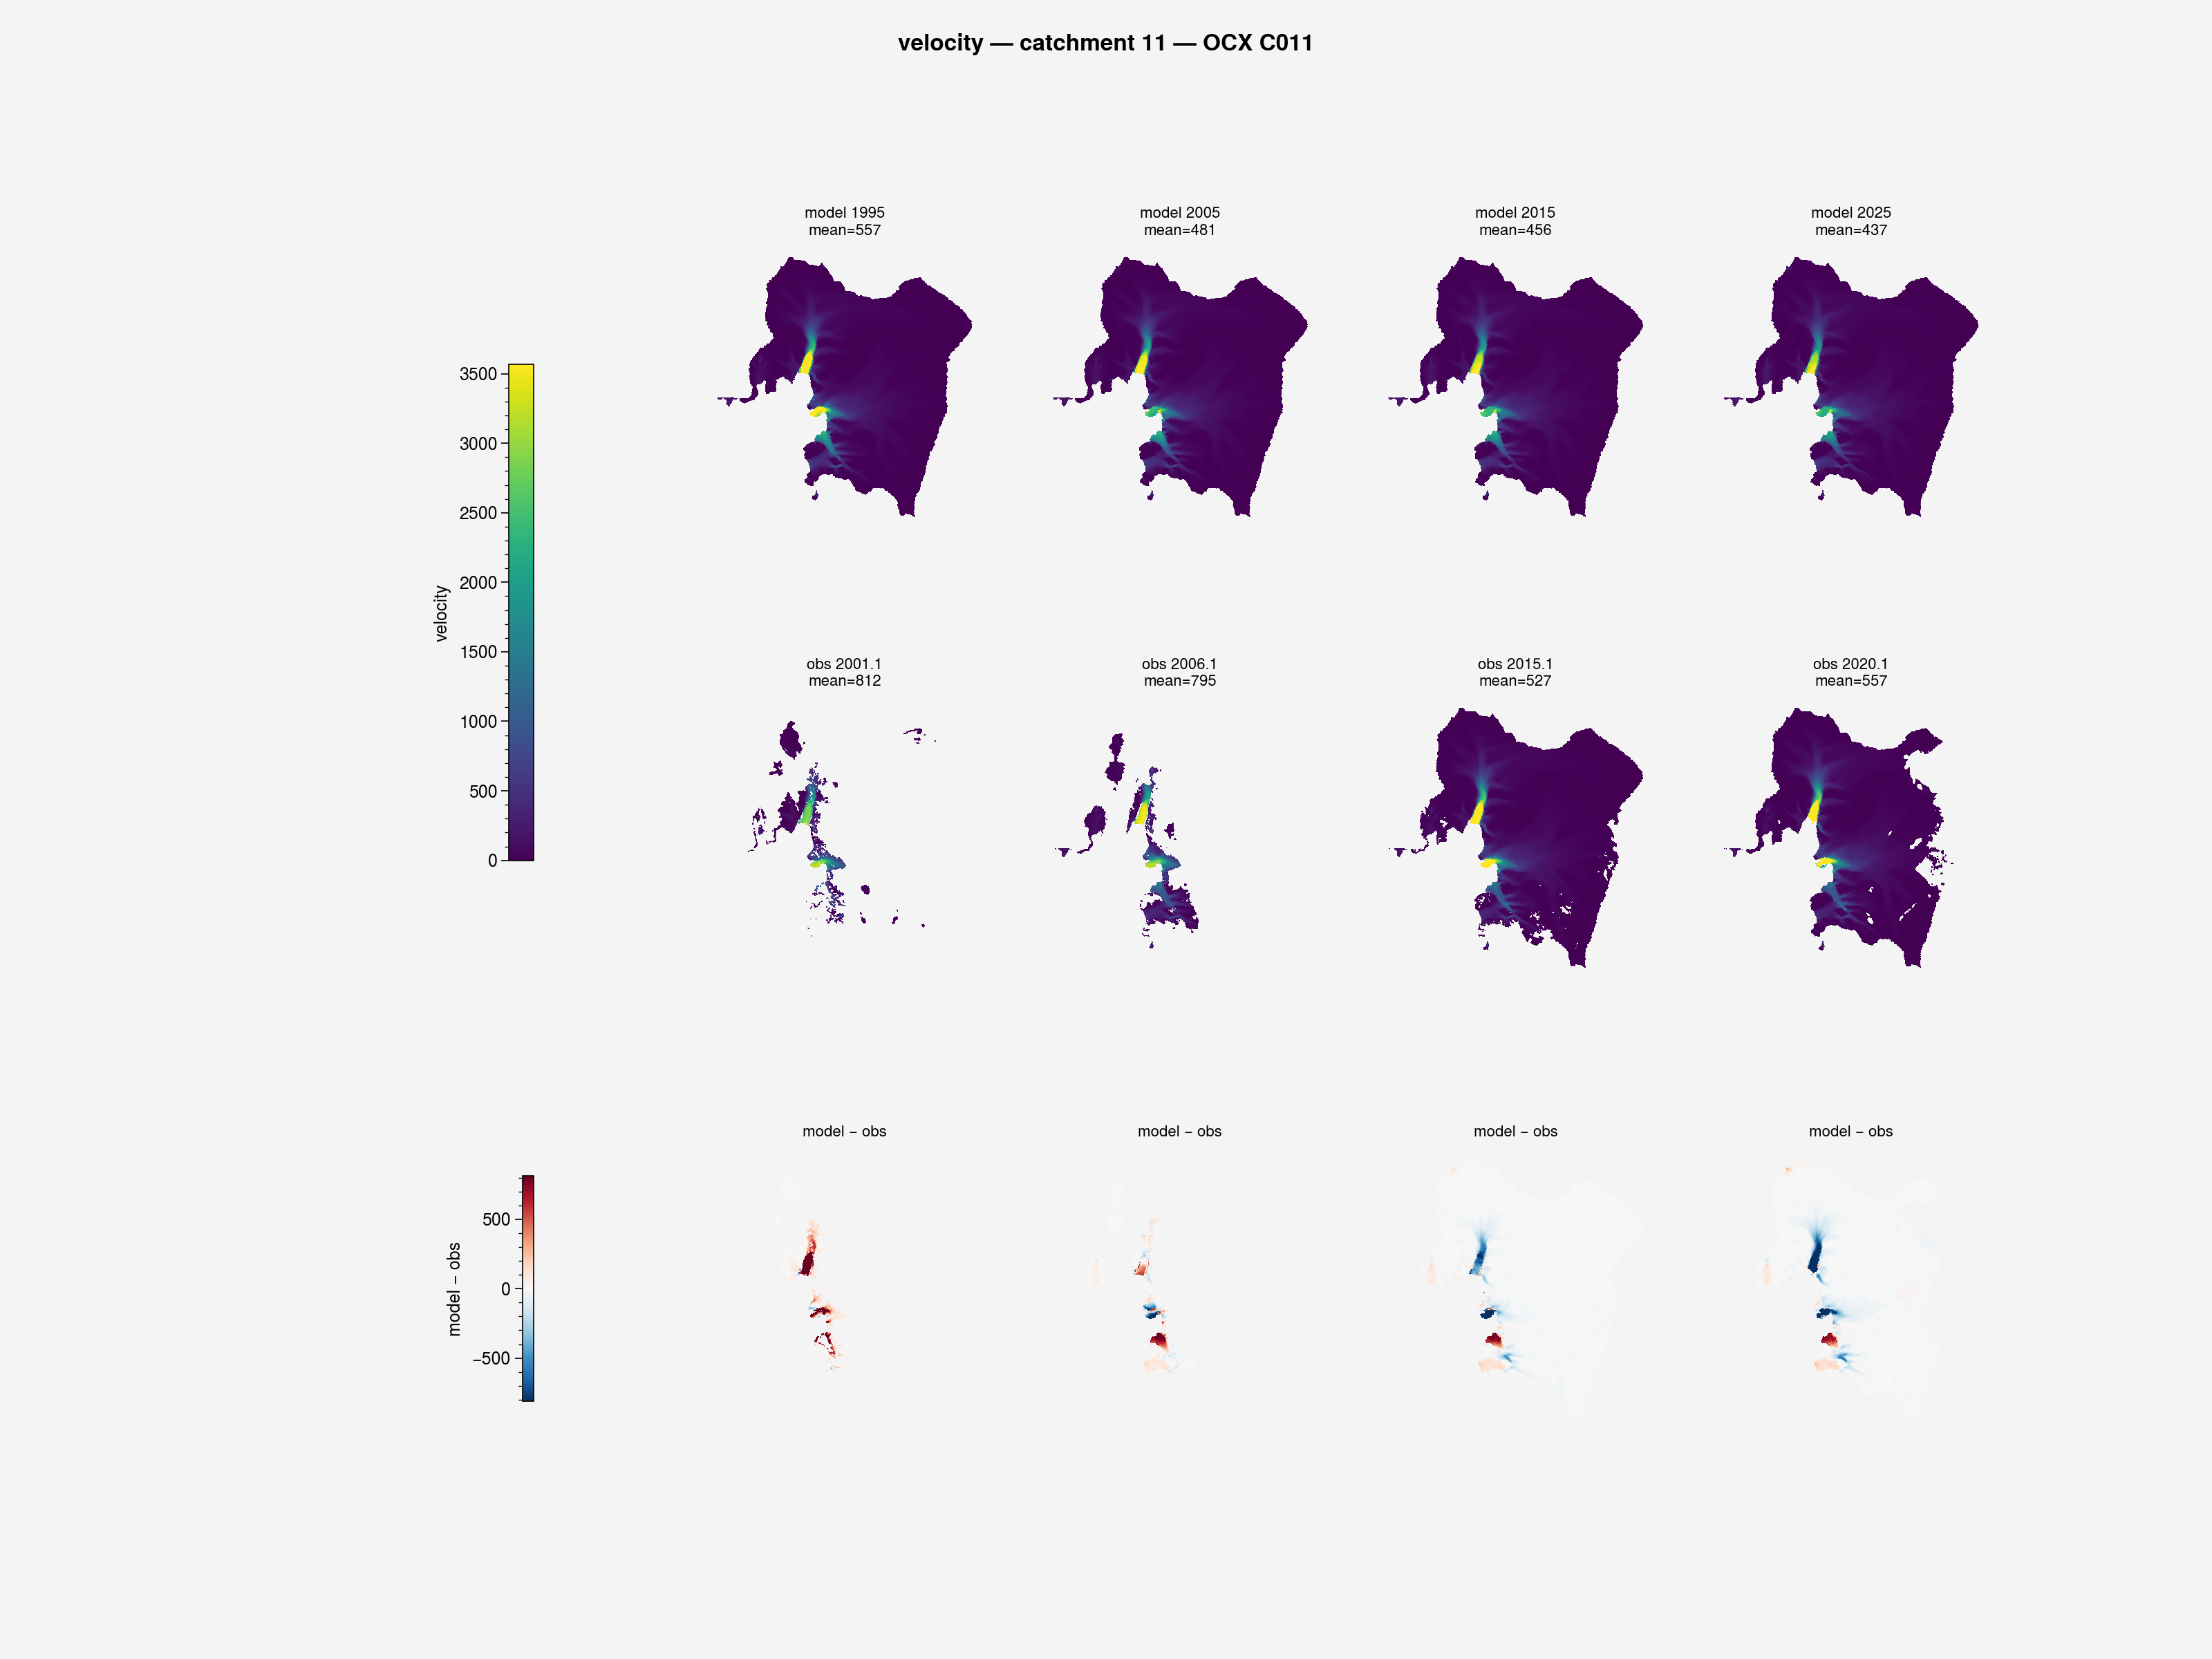

In [19]:
def plot_temporal_maps(
    catchment: int, fpath, kind: str = CONFIG.member_kind, variable: str = "velocity",
    years_to_plot: list = (2001, 2005, 2010, 2014), show_obs: bool = True,
    cmap_abs: str = "viridis", cmap_diff: str = "RdBu_r",
    vmin_abs: float = None, vmax_abs: float = None, vmax_diff: float = None,
):
    """Rows: model | obs | (model-obs); one column per year.

    Titles include each panel's catchment-mean value. The colour scale is
    shared across columns (needed for a fair year-to-year comparison), which
    means real but modest changes -- a few percent over a decade is typical
    for most catchments -- can be hard to see by eye, especially where a
    fast-flowing core saturates the colormap. The mean annotation makes the
    real (if visually subtle) change legible even when the maps look similar.
    """
    xlim, ylim = get_catchment_bounds(catchment)
    catch_mask = get_catchment_mask(catchment)
    n_years = len(years_to_plot)
    n_rows  = 3 if show_obs else 1

    def _mod_obs(year):
        t_idx = int(np.argmin(np.abs(times - year)))
        mod_da = load_model_snapshot_ugrid(fpath, variable, t_idx, kind=kind)
        obs_da, obs_date = (get_obs_velocity_at_year(year) if variable == "velocity"
                            else get_obs_dhdt_at_year(year))
        return t_idx, mod_da, obs_da, obs_date

    if any(v is None for v in [vmin_abs, vmax_abs, vmax_diff]):
        all_abs, all_diff = [], []
        for year in years_to_plot:
            _, mod_da, obs_da, _ = _mod_obs(year)
            mod, obs = mod_da.values, obs_da.values
            all_abs.extend([mod[catch_mask & np.isfinite(mod)], obs[catch_mask & np.isfinite(obs)]])
            d = (mod - obs)[catch_mask & np.isfinite(mod - obs)]
            all_diff.append(d)
        flat_abs  = np.concatenate(all_abs)
        flat_diff = np.concatenate(all_diff)
        if vmin_abs  is None: vmin_abs  = 0.0 if variable == "velocity" else np.nanpercentile(flat_abs, 2)
        if vmax_abs  is None: vmax_abs  = np.nanpercentile(flat_abs, 98)
        if vmax_diff is None: vmax_diff = np.nanpercentile(np.abs(flat_diff[np.isfinite(flat_diff)]), 95)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_years, figsize=(4*n_years, 4*n_rows))
    if n_rows == 1:
        axes = axes[None, :]

    p_abs = p_diff = None
    for col, year in enumerate(years_to_plot):
        t_idx, mod_da, obs_da, obs_date = _mod_obs(year)
        mod_mean = np.nanmean(np.where(catch_mask, mod_da.values, np.nan))
        p_abs = plot_catchment_field(axes[0, col], mod_da, catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
        axes[0, col].set_title(f"model {int(times[t_idx])}\nmean={mod_mean:.0f}", fontsize=8)
        if show_obs:
            obs_mean = np.nanmean(np.where(catch_mask, obs_da.values, np.nan))
            p_abs = plot_catchment_field(axes[1, col], obs_da, catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
            axes[1, col].set_title(f"obs {obs_date}\nmean={obs_mean:.0f}", fontsize=8)
            diff_da = mod_da - obs_da
            p_diff = plot_catchment_field(axes[2, col], diff_da, catchment, xlim, ylim, cmap_diff, -vmax_diff, vmax_diff)
            axes[2, col].set_title("model − obs", fontsize=8)
        for r in range(n_rows):
            axes[r, col].set_xlim(xlim); axes[r, col].set_ylim(ylim)
            axes[r, col].set_aspect("equal"); axes[r, col].axis("off")

    if p_abs  is not None:
        rows = [axes[0, c] for c in range(n_years)] + ([axes[1, c] for c in range(n_years)] if show_obs else [])
        fig.colorbar(p_abs, ax=rows, location="left", shrink=0.6, label=variable)
    if p_diff is not None:
        fig.colorbar(p_diff, ax=[axes[2, c] for c in range(n_years)], location="left", shrink=0.6, label="model − obs")
    fig.suptitle(f"{variable} — catchment {catchment} — {'OCX C011' if kind=='ocx' else Path(fpath).parent.name}",
                fontsize=12)
    return fig, axes

plot_temporal_maps(catchment=11, fpath=MEMBER_PATH, variable="velocity",
                   years_to_plot=[2001, 2005, 2010, 2014] if CONFIG.member_kind != "ocx"
                                 else [1995, 2005, 2015, 2025])

### 1c — Run vs run: difference maps

In [ ]:
# ── Run vs run: where did the physics change actually do something? ──────────
# 3 panels: run A | run B | (A − B), for one catchment and year.
# Only meaningful once RUNS has 2+ entries (uncomment the second one above).
run_labels = list(members["run"].values)
if len(run_labels) >= 2:
    plot_run_diff_2d(run_labels[0], run_labels[1], catchment=11, year=2015,
                     variable="velocity")
    plot_run_diff_2d(run_labels[0], run_labels[1], catchment=11, year=2015,
                     variable="dhdt")
else:
    print(f"Only one run declared ({run_labels[0]}) -> nothing to difference. "
          "Add a second entry to RUNS.")